# Clase 2 — Matemáticas Aplicadas con Python
**Máster en Inteligencia Artificial · Módulo 1 · Unidad 1 · DevSeniorCode**

**Antes de empezar:** verifica que el kernel diga `Python (master-ia)` arriba a la derecha.

## Verificación del entorno
Ejecuta esto primero.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print("\n✅ Entorno listo")

NumPy  : 2.4.3
Pandas : 3.0.1

✅ Entorno listo


---
---
# Bloque A — Álgebra Lineal con NumPy

El director de ShopSmart preguntó: *"¿Cómo va a procesar el modelo la información de los 500 clientes?"*

Un modelo no lee texto ni tablas. Solo entiende números en estructuras matemáticas específicas: **escalares, vectores, matrices y tensores**.

### Celda 1 — Los cuatro objetos fundamentales


In [10]:
import numpy as np
import pandas as pd

# ── ESCALAR ──────────────────────────────────────────────────────
gasto = np.array(323.81)

print("ESCALAR")
print(f"  Valor : {gasto}")
print(f"  Shape : {gasto.shape}")
print(f"  ndim  : {gasto.ndim}")

print()

# ── VECTOR ───────────────────────────────────────────────────────
cli_0001 = np.array([72, 2, 323.81, 1, 0])
#                    ↑   ↑    ↑      ↑   ↑
#                  dias comp gasto  cat cancel

print("VECTOR — CLI-0001")
print(f"  Valor : {cli_0001}")
print(f"  Shape : {cli_0001.shape}")
print(f"  ndim  : {cli_0001.ndim}")
print()
print(f"  cli_0001[0]   = {cli_0001[0]}    ← dias_sin_compra")
print(f"  cli_0001[2]   = {cli_0001[2]}  ← gasto_total")
print(f"  cli_0001[1:3] = {cli_0001[1:3]}  ← compras y gasto")

print()

# ── MATRIZ ───────────────────────────────────────────────────────
X_mini = np.array([
    [ 72,  2, 323.81, 1, 0],   # CLI-0001
    [339,  5,  79.28, 1, 3],   # CLI-0002
    [  6,  2, 136.66, 1, 0],   # CLI-0003
    [ 15,  9, 987.50, 4, 1],   
    [210,  1,  42.00, 1, 4],   
])

print("MATRIZ — 5 clientes, 5 características")
print(f"  Shape : {X_mini.shape}")
print(f"  ndim  : {X_mini.ndim}")
print()
print(X_mini)
print()
print(f"  X_mini[0, :]  = {X_mini[0, :]}  ← fila 0 completa")
print(f"  X_mini[:, 0]  = {X_mini[:, 0]}   ← columna 0 completa")
print(f"  X_mini[1, 2]  = {X_mini[1, 2]}      ← fila 1, col 2")

ESCALAR
  Valor : 323.81
  Shape : ()
  ndim  : 0

VECTOR — CLI-0001
  Valor : [ 72.     2.   323.81   1.     0.  ]
  Shape : (5,)
  ndim  : 1

  cli_0001[0]   = 72.0    ← dias_sin_compra
  cli_0001[2]   = 323.81  ← gasto_total
  cli_0001[1:3] = [  2.   323.81]  ← compras y gasto

MATRIZ — 5 clientes, 5 características
  Shape : (5, 5)
  ndim  : 2

[[ 72.     2.   323.81   1.     0.  ]
 [339.     5.    79.28   1.     3.  ]
 [  6.     2.   136.66   1.     0.  ]
 [ 15.     9.   987.5    4.     1.  ]
 [210.     1.    42.     1.     4.  ]]

  X_mini[0, :]  = [ 72.     2.   323.81   1.     0.  ]  ← fila 0 completa
  X_mini[:, 0]  = [ 72. 339.   6.  15. 210.]   ← columna 0 completa
  X_mini[1, 2]  = 79.28      ← fila 1, col 2


### Celda 2 — Cargar el CSV y construir la matriz X

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('clientes_shopSmart.csv')

print(f"Dataset: {df.shape[0]} clientes, {df.shape[1]} columnas")
print()
print(df.head(3))
print()

columnas_numericas = ['dias_sin_compra', 'num_compras', 'gasto_total',
                      'num_categorias', 'cancelaciones']

X = df[columnas_numericas].values.astype(float)
y = df['volvio'].values.astype(float)

print(f"X.shape = {X.shape}")
print(f"y.shape = {y.shape}")
print()
print(f"Volvieron   : {int(y.sum())}  ({y.mean()*100:.1f}%)")
print(f"No volvieron: {int((y==0).sum())}  ({(1-y.mean())*100:.1f}%)")

Dataset: 500 clientes, 13 columnas

  cliente_id segmento    ciudad canal_compra                 email  \
0   CLI-0001  Regular  Medellín          App    cliente1@yahoo.com   
1   CLI-0002  Dormido  Medellín          Web                   NaN   
2   CLI-0003    Nuevo    Bogotá          Web  cliente3@outlook.com   

  fecha_ultima_compra  dias_sin_compra  num_compras  gasto_total  \
0          2026-01-16               72            2       323.81   
1          2025-04-24              339            5        79.28   
2          23/03/2026                6            2       136.66   

   num_categorias  cancelaciones categoria_favorita  volvio  
0               1              0           Deportes       0  
1               1              3            Belleza       0  
2               1              0               Ropa       1  

X.shape = (500, 5)
y.shape = (500,)

Volvieron   : 316  (63.2%)
No volvieron: 184  (36.8%)


### Celda 3 — Broadcasting, axis y normalización

**Regla de axis:**
- `axis=0` → flecha **↓** → resultado por columna
- `axis=1` → flecha **→** → resultado por fila

In [15]:
import numpy as np
import pandas as pd

df = pd.read_csv('clientes_shopSmart.csv')
columnas_numericas = ['dias_sin_compra', 'num_compras', 'gasto_total',
                      'num_categorias', 'cancelaciones']
X = df[columnas_numericas].values.astype(float)

# ── Broadcasting ──────────────────────────────────────────────────
gasto_todos = X[:, 2]
gasto_miles = gasto_todos / 1000    # ← divide cada elemento por 1000

print(f"Gastos en pesos (5): {gasto_todos[:5]}")
print(f"Gastos en miles (5): {gasto_miles[:5].round(3)}")
print()

# ── axis=0 vs axis=1 ──────────────────────────────────────────────
promedios_col = np.mean(X, axis=0)   # ← flecha ↓ → por columna
promedios_fil = np.mean(X, axis=1)   # ← flecha → → por fila

print(f"axis=0 → shape: {promedios_col.shape}  ← uno por característica")
print(f"axis=1 → shape: {promedios_fil.shape}  ← uno por cliente")
print()

# ── Normalización Min-Max ──────────────────────────────────────────
X_min  = X.min(axis=0)    # ← mínimo de cada columna
X_max  = X.max(axis=0)    # ← máximo de cada columna
X_norm = (X - X_min) / (X_max - X_min)    # ← fórmula min-max

print("Antes (primeras 3 filas):")
print(X[:3])
print("\nDespués — normalizado:")
print(X_norm[:3].round(4))
print(f"\nRango antes  — dias: [{X[:,0].min():.0f}, {X[:,0].max():.0f}]")
print(f"Rango después — dias: [{X_norm[:,0].min():.2f}, {X_norm[:,0].max():.2f}]")

Gastos en pesos (5): [323.81  79.28 136.66 166.2  121.09]
Gastos en miles (5): [0.324 0.079 0.137 0.166 0.121]

axis=0 → shape: (5,)  ← uno por característica
axis=1 → shape: (500,)  ← uno por cliente

Antes (primeras 3 filas):
[[ 72.     2.   323.81   1.     0.  ]
 [339.     5.    79.28   1.     3.  ]
 [  6.     2.   136.66   1.     0.  ]]

Después — normalizado:
[[0.1839 0.0357 0.0606 0.     0.    ]
 [0.8756 0.1429 0.0114 0.     0.6   ]
 [0.013  0.0357 0.0229 0.     0.    ]]

Rango antes  — dias: [1, 387]
Rango después — dias: [0.00, 1.00]


### Celda 4 — El producto punto: cómo predice el modelo

In [21]:
import numpy as np
import pandas as pd

a     = np.array([1, 2, 3])
b_vec = np.array([4, 5, 6])

# np.array(a, axis=0) → [5, 7, 9]
# np.array(a, axis=1) → [6, 15]

manual   = 1 * 4 + 2 * 5 + 3 * 6    # ← calcula a mano
numpy_dp = np.dot(a, b_vec)
operador = a @ b_vec

print(f"Manual  : {manual}")
print(f"np.dot  : {numpy_dp}")
print(f"a @ b   : {operador}")
print()

# ── Predicción para CLI-0001 ──────────────────────────────────────
x_cli0001 = np.array([0.18, 0.03, 0.06, 0.0, 0.0])
w = np.array([-0.5, 0.8, 0.3, 0.2, -0.4])
b = 0.1

print("Cliente")
prediccion = x_cli0001 @ w + b    # ← producto punto + sesgo

print(f"x·w = {np.dot(x_cli0001, w):.4f}")
print(f"+ b = {b}")
print(f"Predicción: {prediccion:.4f}")
print("Decisión:", "Vuelve" if prediccion > 0 else "No vuelve")
print()

print("Clientes")
# ── Todos los clientes a la vez ───────────────────────────────────
df = pd.read_csv('clientes_shopSmart.csv')
columnas_numericas = ['dias_sin_compra', 'num_compras', 'gasto_total',
                      'num_categorias', 'cancelaciones']
X_raw  = df[columnas_numericas].values.astype(float)
X_norm = (X_raw - X_raw.min(axis=0)) / (X_raw.max(axis=0) - X_raw.min(axis=0))

predicciones = X_norm @ w + b    # ← todos los clientes a la vez

print(f"X_norm.shape = {X_norm.shape}  ×  w.shape = {w.shape}  →  {predicciones.shape}")
print(f"Predicciones 'Sí vuelve': {(predicciones > 0).sum()}")
print(f"Predicciones 'No vuelve': {(predicciones <= 0).sum()}")

Manual  : 32
np.dot  : 32
a @ b   : 32

Cliente
x·w = -0.0480
+ b = 0.1
Predicción: 0.0520
Decisión: Vuelve

Clientes
X_norm.shape = (500, 5)  ×  w.shape = (5,)  →  (500,)
Predicciones 'Sí vuelve': 373
Predicciones 'No vuelve': 127


### Celda 5 — numpy.linalg: norma y transpuesta

In [22]:
import numpy as np

# ── NORMA ─────────────────────────────────────────────────────────
ejemplo = np.array([3.0, 4.0])
norma   = np.linalg.norm(ejemplo)

print(f"v = {ejemplo}  →  norma = {norma:.1f}  (triángulo 3-4-5)")

print()

w_inicial = np.array([0.0, 0.0, 0.0, 0.0, 0.0])
w_final   = np.array([-0.42, 0.71, 0.28, 0.15, -0.35])
print(f"Norma w inicial: {np.linalg.norm(w_inicial):.4f}  ← modelo no sabe nada")
print(f"Norma w final  : {np.linalg.norm(w_final):.4f}  ← modelo aprendió")
print()

# ── TRANSPUESTA ───────────────────────────────────────────────────
M   = np.array([[1, 2, 3, 4, 5],
                [6, 7, 8, 9, 10]])
M_T = M.T

print(f"M    shape: {M.shape}")
print(M)
print(f"\nM.T  shape: {M_T.shape}")
print(M_T)


v = [3. 4.]  →  norma = 5.0  (triángulo 3-4-5)

Norma w inicial: 0.0000  ← modelo no sabe nada
Norma w final  : 0.9507  ← modelo aprendió

M    shape: (2, 5)
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]

M.T  shape: (5, 2)
[[ 1  6]
 [ 2  7]
 [ 3  8]
 [ 4  9]
 [ 5 10]]


---
---
# Bloque B — Descenso del Gradiente

---

En el Bloque A pusimos pesos inventados. La pregunta del director: *"¿Y cómo sabe el modelo cuáles son los correctos?"*

**Descenso del Gradiente** — los aprende solo, iteración tras iteración.

---

### La fórmula
```
w_nuevo = w_actual − α × ∇L(w)
```

| Símbolo | Nombre | Qué hace |
|---|---|---|
| `w` | Peso | El número que el modelo ajusta |
| `α` | Learning Rate | Tamaño del paso |
| `∇L(w)` | Gradiente | Hacia dónde sube el error |
| `−` | Signo menos | Ir en la dirección opuesta |

---

### MSE — la función de pérdida
```
MSE = (1/n) × Σ (predicción_i − real_i)²
```
Cuanto más grande, más equivocado. El objetivo: **minimizarlo**.

### Micro-ejercicio — 1 cliente, 1 peso, 1 paso


In [ ]:
x      = 0.8    # dias_sin_compra normalizado — alto = muy inactivo
y_real = 0      # no volvió
w      = 0.5    # peso inicial
b      = 0.0
lr     = 0.1

# Paso 1 — predicción:  w * x + b
prediccion  = w * X + b

# Paso 2 — error:  prediccion - y_real
error       = prediccion - y_real

# Paso 3 — pérdida MSE (1 dato):  error ** 2
perdida     = ___

# Paso 4 — gradiente de w:  2 * error * x
# (x multiplica porque el error se propagó a través de x en prediccion = w*x)
gradiente_w = ___

# Paso 5 — actualizar w:  w - lr * gradiente_w
w_nuevo     = ___

print(f"Predicción  : {prediccion}")
print(f"Error       : {error}")
print(f"Pérdida     : {perdida}")
print(f"Gradiente w : {gradiente_w}")
print(f"w anterior  : {w}")
print(f"w nuevo     : {w_nuevo}")
print()

Predicción  : 
Error       : 
Pérdida     : 
Gradiente w : 
w anterior  : 0.5
w nuevo     : 



### Celda 6 — Gradiente completo con los 500 clientes

In [24]:
import numpy as np
import pandas as pd

df = pd.read_csv('clientes_shopSmart.csv')
columnas_numericas = ['dias_sin_compra', 'num_compras', 'gasto_total',
                      'num_categorias', 'cancelaciones']
X_raw = df[columnas_numericas].values.astype(float)
y     = df['volvio'].values.astype(float)
X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X     = (X_raw - X_min) / (X_max - X_min)
n, n_features = X.shape

w = np.zeros(n_features)
b = 0.0

learning_rate = 0.05
n_epocas      = 200
historial_perdida = []

print(f"{'Época':>6} | {'Pérdida (MSE)':>13} | Pesos w")
print("─" * 70)

for epoca in range(n_epocas):

    predicciones = X @ w + b            # Paso 1
    errores      = predicciones - y     # Paso 2
    perdida      = np.mean(errores**2)  # Paso 3
    historial_perdida.append(perdida)

    gradiente_w = (X.T @ errores) / n   # Paso 4

    gradiente_b = np.mean(errores)      # Paso 4

    w = w - learning_rate * gradiente_w  # Paso 5
    b = b - learning_rate * gradiente_b

    if epoca % 25 == 0 or epoca == n_epocas - 1:
        w_str = '[' + ', '.join(f'{wi:+.3f}' for wi in w) + ']'
        print(f"  {epoca:4d}  | {perdida:13.6f} | {w_str}")

print(f"\nPérdida inicial : {historial_perdida[0]:.6f}")
print(f"Pérdida final   : {historial_perdida[-1]:.6f}")
print(f"Reducción       : {(1 - historial_perdida[-1]/historial_perdida[0])*100:.1f}%")
print()
print("Pesos aprendidos:")
for col, peso in zip(columnas_numericas, w):
    signo = "↑ más probable volver" if peso > 0 else "↓ menos probable volver"
    print(f"  {col:25s}: {peso:+.4f}  {signo}")
print(f"\n  Sesgo b = {b:.4f}")

 Época | Pérdida (MSE) | Pesos w
──────────────────────────────────────────────────────────────────────
     0  |      0.632000 | [+0.004, +0.007, +0.006, +0.013, +0.006]
    25  |      0.237135 | [+0.022, +0.100, +0.090, +0.170, +0.057]
    50  |      0.216931 | [-0.013, +0.126, +0.115, +0.208, +0.038]
    75  |      0.211309 | [-0.053, +0.137, +0.126, +0.222, +0.009]
   100  |      0.207280 | [-0.092, +0.144, +0.133, +0.227, -0.018]
   125  |      0.204086 | [-0.127, +0.149, +0.138, +0.230, -0.042]
   150  |      0.201492 | [-0.160, +0.152, +0.141, +0.230, -0.062]
   175  |      0.199348 | [-0.190, +0.154, +0.142, +0.228, -0.080]
   199  |      0.197615 | [-0.216, +0.155, +0.143, +0.225, -0.095]

Pérdida inicial : 0.632000
Pérdida final   : 0.197615
Reducción       : 68.7%

Pesos aprendidos:
  dias_sin_compra          : -0.2161  ↓ menos probable volver
  num_compras              : +0.1548  ↑ más probable volver
  gasto_total              : +0.1433  ↑ más probable volver
  num_categor

### Celda 7 — Visualizar el aprendizaje

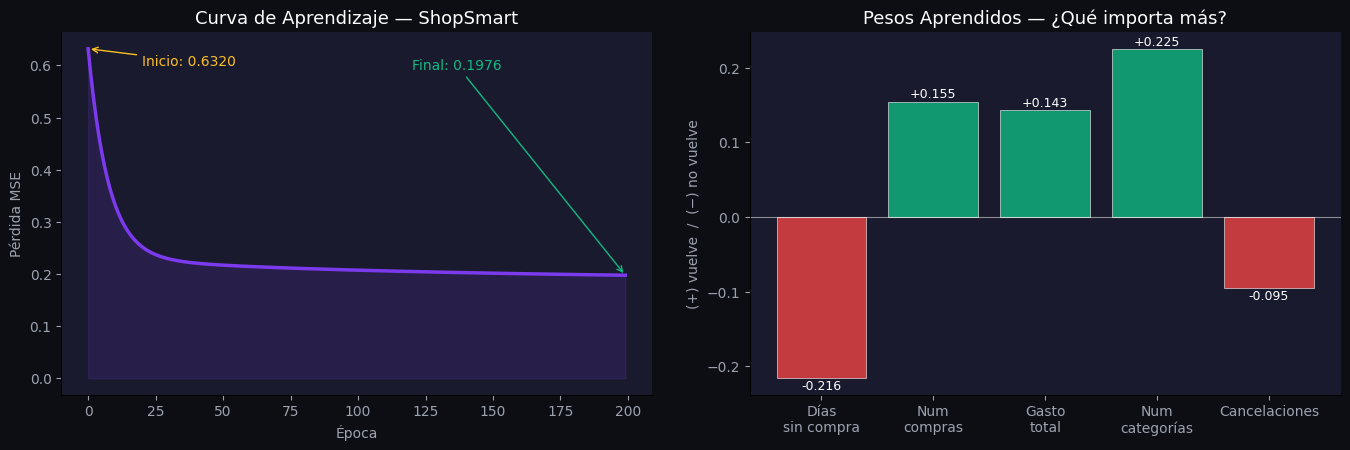

✅ Guardado como 'aprendizaje_shopSmart.png'


In [ ]:
import matplotlib.pyplot as plt

# historial_perdida, w, columnas_numericas vienen de la celda anterior

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d0d14')

# ── Curva de aprendizaje ──────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
ax1.plot(range(len(historial_perdida)), ___, color='#7c3aed', linewidth=2.5)
ax1.set_title('Curva de Aprendizaje', color='white', fontsize=13)
ax1.set_xlabel(___, color='#9ca3af')   # ← ¿qué va en el eje X?
ax1.set_ylabel(___, color='#9ca3af')   # ← ¿qué va en el eje Y?
ax1.tick_params(colors='#9ca3af')
for s in ['top','right']: ax1.spines[s].set_visible(False)

# ── Pesos aprendidos ──────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
nombres = ['Días sin compra', 'Num  compras', 'Gasto total', 'Num categorías', 'Cancelaciones']
colores = ['#10b981' if p > 0 else '#ef4444' for p in ___]   # ← ¿qué lista?
ax2.bar(nombres, ___, color=colores, alpha=0.8)               # ← ¿qué valores?
ax2.axhline(y=0, color='white', linewidth=0.8, alpha=0.5)
ax2.set_title('Pesos Aprendidos', color='white', fontsize=13)
ax2.tick_params(colors='#9ca3af')
for s in ['top','right']: ax2.spines[s].set_visible(False)

plt.tight_layout()
plt.show()

### Celda 8 — Experimento del learning rate

**Qué debe hacer:**
1. Definir una función `entrenar(learning_rate, n_epocas=100)` que devuelva el historial de pérdidas
2. Probar tres valores: `0.001`, `0.05`, `2.0`
3. Graficar los tres historiales en subplots lado a lado con diagnóstico en cada panel

**Pistas (solo si llevas más de 3 minutos bloqueado):**
- ¿Puedes reutilizar el bucle de la Celda 6 dentro de una función?
- `np.isfinite()` te dice si un número se disparó a infinito

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('clientes_shopSmart.csv')
columnas_numericas = ['dias_sin_compra', 'num_compras', 'gasto_total',
                      'num_categorias', 'cancelaciones']
X_raw = df[columnas_numericas].values.astype(float)
y     = df['volvio'].values.astype(float)
X     = (X_raw - X_raw.min(axis=0)) / (X_raw.max(axis=0) - X_raw.min(axis=0))
n     = len(X)

# Tu código aquí ↓